In [1]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

import numpy as np
import math
import matplotlib.pyplot as plt
plt.style.use('default')
import matplotlib
import pandas as pd
import os
import re
from tqdm import tqdm
color_array=np.linspace(0,1,11)
cmap = plt.cm.tab20b
filename = 'g4simple_out_k_42_nt_g4sntuple.csv'

In [2]:
# Skip the initial rows that do not contain data
skip_rows = 24  # Adjust based on your file's header lines
r_min = 0 
r_max = 100 #34.5 
# Define column names as they appear in your CSV file
column_names = ['nEvents', 'event', 'pid', 'trackID', 'parentID', 'step', 'KE', 'Edep', 'x', 'y', 'z', 'lx', 'ly', 'lz', 'pdx', 'pdy', 'pdz', 't', 'volID', 'iRep']

# Load the data, skipping the header rows and assigning column names
data = pd.read_csv(filename, skiprows=skip_rows, header=None, names=column_names)
# Filter for hits where energy was deposited in the detector volume
detector_hits = data.loc[(data['Edep']>0) & (data['volID'] == 1) & ((data['x']**2 + data['y']**2)**0.5<r_max)]

# Process the DataFrame to match the required structure
proc_df = detector_hits.rename(columns={'iRep': 'detID', 'Edep': 'edep'}).copy()
proc_df['edep'] *= 1000  # Convert 'edep' to keV
proc_df['z_hit'] = abs(proc_df['z'] - round(proc_df['z'].min(), 2))  # Adjust 'z_hit' if needed
proc_df['e_total'] = proc_df.groupby('event')['edep'].transform('sum')  # Calculate total deposited energy per event

# Select and rename columns to match the expected output structure
proc_df = proc_df[['event', 'x', 'y', 'z_hit', 'edep', 'volID', 'detID', 'e_total']]
proc_df.rename(columns={'x': 'x_hit', 'y': 'y_hit'}, inplace=True)

proc_df['r_hit'] = ((proc_df['x_hit']**2 + proc_df['y_hit']**2)**0.5)#.round(5)

Minimum z with field > 0: 0.0
Radial range at z_min with field > 0: 1.4 - 30.0
Filtered proc_df has 2803868 rows within radial range 1.4 - 30.0.


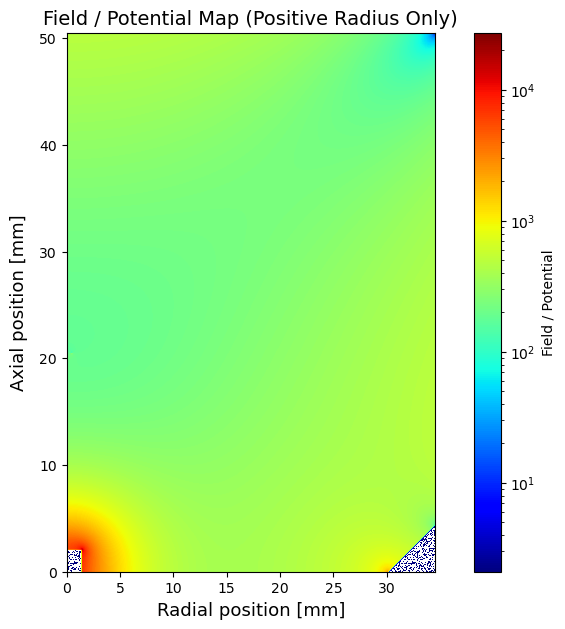

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
field_dir = '/work/users/k/b/kbhimani/EH-Drift_data/fields/'
det='ponama_1' #'ponama_1' 'V07647A' 
# Step 1: Load field data
data = np.loadtxt(field_dir + f'ev_fin_{det}_grid=0.0200_sc=-0.3000.dat')
r = np.unique(data[:, 0])  # Unique radial positions
z = np.unique(data[:, 1])  # Unique axial positions
field_values = data[:, 3]  # Field or potential values

field_vals = field_values.reshape(len(r), len(z))
field_vals[field_vals < 0] = 0  # Set negative values to 0

# Step 2: Find minimum z and corresponding r values where field > 0
valid_indices = np.where(data[:, 3] > 0)  # Indices where field > 0
r_valid = data[valid_indices, 0].flatten()  # Radial positions where field > 0
z_valid = data[valid_indices, 1].flatten()  # Axial positions where field > 0

# Identify the minimum z among valid points
z_min = z_valid.min()

# Get r values corresponding to the minimum z
z_min_indices = np.where((data[:, 1] == z_min) & (data[:, 3] > 0))
r_at_z_min = data[z_min_indices, 0].flatten()  # Radial values at z_min where field > 0

# Calculate r_min and r_max
r_min, r_max = r_at_z_min.min(), r_at_z_min.max()

print(f"Minimum z with field > 0: {z_min}")
print(f"Radial range at z_min with field > 0: {r_min} - {r_max}")

# Step 3: Filter proc_df based on r_min and r_max
proc_df = proc_df[(proc_df['r_hit'] >= r_min) & (proc_df['r_hit'] <= r_max)]

print(f"Filtered proc_df has {len(proc_df)} rows within radial range {r_min} - {r_max}.")

# Step 4: Visualize the field values for positive radial side
bounds = (min(r), max(r), min(z), max(z))
fig = plt.figure(figsize=(10, 7))
ip = plt.imshow(field_vals.T, norm=colors.LogNorm(),
                extent=bounds,  # Boundaries of the edges of the 'image' data
                origin="lower",  # Origin at the bottom-left
                cmap='jet')  # Use 'jet' colormap
plt.xlabel("Radial position [mm]", size=13)
plt.ylabel("Axial position [mm]", labelpad=8, size=13)
plt.colorbar(label="Field / Potential")
plt.title("Field / Potential Map (Positive Radius Only)", size=14)
plt.show()


Text(0.5, 1.0, 'G4 Simple Total Energy Deposition Spectrum')

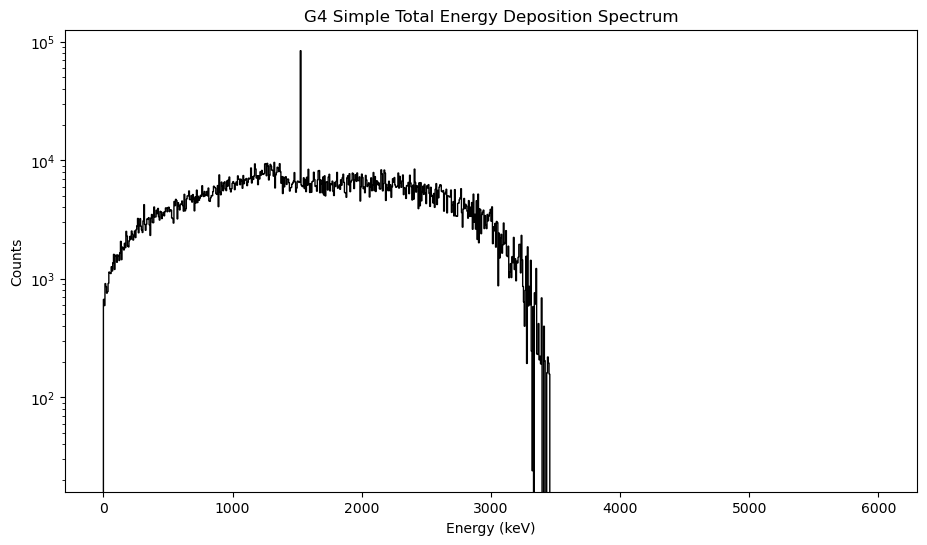

In [4]:
plt.figure(figsize=(11, 6))
hist, bins, _ = plt.hist(proc_df['e_total'], bins=1000, range=(0, 6000), histtype='step', color='k')
# plt.axvline(2614.53, color='k', alpha=0.5)

plt.yscale('log')
plt.xlabel('Energy (keV)')
plt.ylabel('Counts')
plt.title('G4 Simple Total Energy Deposition Spectrum')

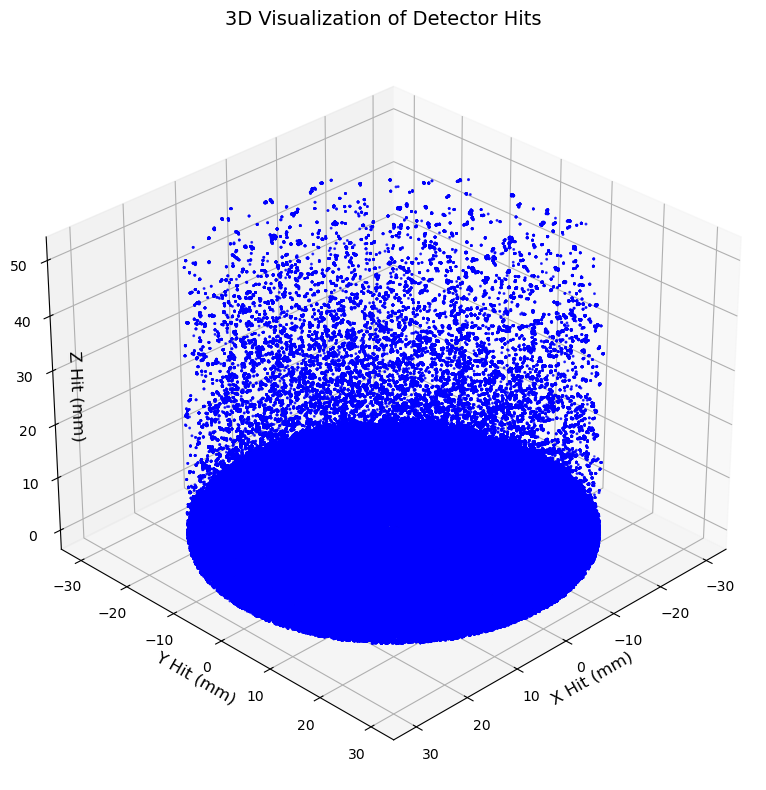

In [5]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the data
ax.scatter(
    proc_df['x_hit'], 
    proc_df['y_hit'], 
    proc_df['z_hit'], 
    s=1, alpha=0.5, c='b'
)

# Set axis labels
ax.set_xlabel('X Hit (mm)', fontsize=12, labelpad=0) 
ax.set_ylabel('Y Hit (mm)', fontsize=12, labelpad=0)
ax.set_zlabel('Z Hit (mm)', fontsize=12, labelpad=-30)
ax.set_title('3D Visualization of Detector Hits', fontsize=14)

# Adjust the view angle
ax.view_init(elev=30, azim=45)

# Automatically adjust layout
plt.tight_layout()
plt.show()


Text(0.5, 0, 'X hit (mm)')

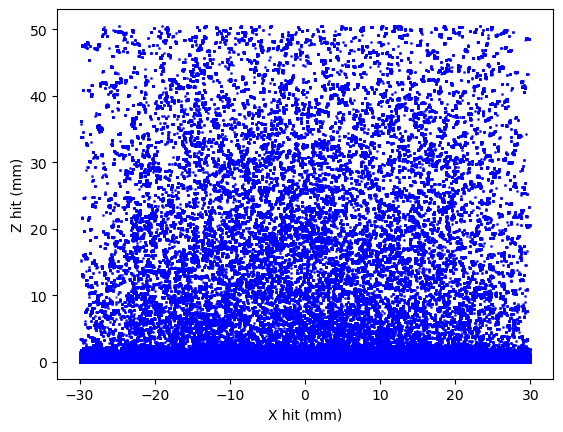

In [6]:
plt.plot(proc_df['x_hit'], proc_df['z_hit'],'bo', markersize=1, alpha=0.5)
plt.ylabel('Z hit (mm)')
plt.xlabel('X hit (mm)')

100%|██████████| 1/1 [00:04<00:00,  4.51s/it]


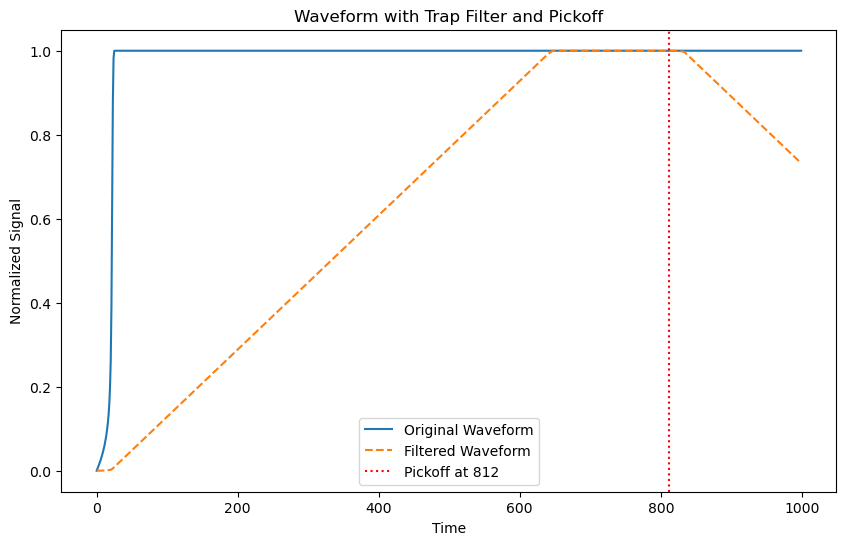

Index(['r', 'z', 'eng', 'sc', 'sf_drift', 'grid', 'pass_thickness',
       'self_repulsion', 'det', 'wf', 'energy_estimate'],
      dtype='object')


In [7]:
# directory = f'/nas/longleaf/home/kbhimani/EH-Drift/waveforms/{detector}'
import sys
sys.path.append('/nas/longleaf/home/kbhimani/EH-Drift/Analysis')

from tools import (
    load_waveform_data,
    compute_pickoff_values_and_plot_random,
    add_tail_slope_to_dataframe,
    calculate_tail_slope,
    query_and_plot_waveform
)

# directory = '/nas/longleaf/home/kbhimani/EH-Drift/Analysis/plot_data/'
# detector = 'ponama_1' # old panoma
# sim_time=8000
# step_time_out = 10
# rise = 4000 
# flat = 3000
# pickoff = 7000

directory = f'/nas/longleaf/home/kbhimani/EH-Drift/waveforms/{det}'
detector = 'ponama_1' # 'ICPC' 'P42575A' 'UNC_scanner' 'ponama_1' 'V00048A' 'P00749A' 'P00661B'
sim_time=16000
step_time_out = 16
rise = 10000 
flat = 3000
pickoff = 13000
waveforms_df = load_waveform_data(directory)
activeness = compute_pickoff_values_and_plot_random(waveforms_df, rise_samp := math.floor(rise/step_time_out), flat_samp := math.floor(flat/step_time_out), pickoff_samp := math.floor(pickoff/step_time_out), plot_random=True)

print(waveforms_df.columns)
# waveforms_df = waveforms_df[waveforms_df['r']>2]

In [8]:
# Filter parameters
filter_det = detector
filter_sc = -0.5
filter_eng = 2039 
filter_sd = 0.001
v_min=0
v_max=1

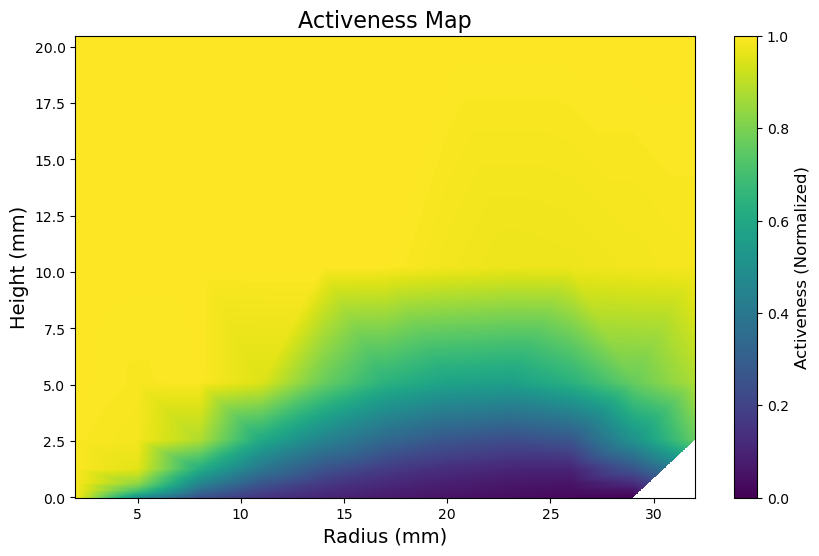

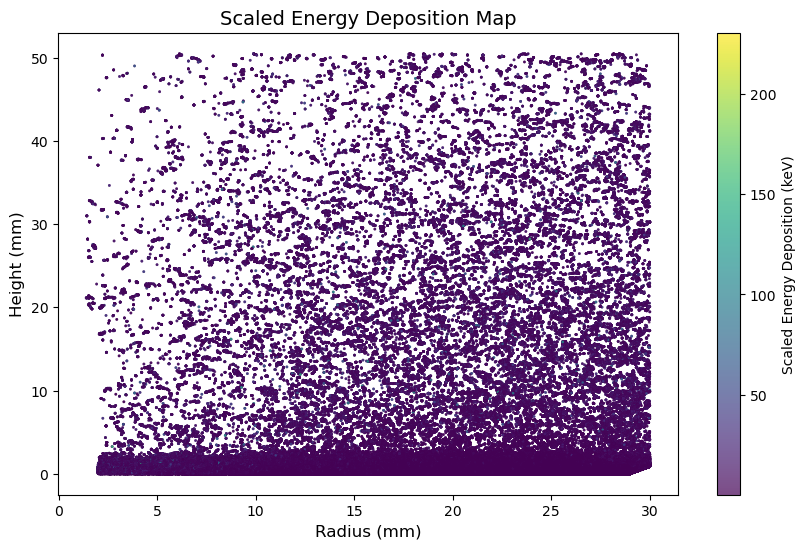

In [9]:
from scipy.interpolate import griddata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm

# Step 1: Add z=0.00 with same activeness as z=0.02 for all unique r
def adjust_activeness_map(waveforms_df):
    """
    Adjust the activeness map by adding points at z=0.00 for all unique r
    with the same values as at z=0.02.
    """
    z_0_02_points = waveforms_df[waveforms_df['z'] == 0.02].copy()
    z_0_02_points['z'] = 0.00  # Set z to 0.00
    adjusted_waveforms_df = pd.concat([waveforms_df, z_0_02_points], ignore_index=True)
    return adjusted_waveforms_df

# Step 2: Interpolate activeness map with cubic interpolation
def interpolate_activeness_map(waveforms_df, grid_size=500):
    # Filter the original DataFrame
    filtered_df = waveforms_df[
        (waveforms_df['det'] == filter_det) & 
        (waveforms_df['sc'] == filter_sc) & 
        (waveforms_df['eng'] == filter_eng) &
        (waveforms_df['sf_drift'] == filter_sd)
    ]
    r_plot = filtered_df['r'].to_numpy()
    z_plot = filtered_df['z'].to_numpy()
    energy_estimate = filtered_df['energy_estimate'].to_numpy()

    r_lin = np.linspace(r_plot.min(), r_plot.max(), grid_size)
    z_lin = np.linspace(0.00, z_plot.max(), grid_size)  # Explicitly include 0.00 in z-grid
    r_grid, z_grid = np.meshgrid(r_lin, z_lin)

    energy_interp = griddata((r_plot, z_plot), energy_estimate, (r_grid, z_grid), method='linear')
    energy_interp_clipped = np.clip(energy_interp, 0, 1)

    return r_grid, z_grid, energy_interp_clipped

# Step 3: Plot the activeness map
def plot_activeness_map(r_grid, z_grid, energy_interp):
    plt.figure(figsize=(10, 6))
    heatmap = plt.pcolormesh(
        r_grid, z_grid, energy_interp, cmap=cm.viridis, shading='auto', vmin=0, vmax=1
    )
    cbar = plt.colorbar(heatmap)
    cbar.set_label('Activeness (Normalized)', fontsize=12)
    cbar.ax.tick_params(labelsize=10)
    plt.xlabel('Radius (mm)', fontsize=14)
    plt.ylabel('Height (mm)', fontsize=14)
    plt.title('Activeness Map', fontsize=16)
    plt.show()

# Step 4: Scale energy depositions with activeness
def scale_energy_with_activeness(proc_df, r_grid, z_grid, energy_interp):
    # Limit to the first 10,000 events
    # Handle z_hit > max(z_grid)
    z_max = z_grid.max()
    proc_df['z'] = proc_df['z_hit']
    proc_df['activeness'] = griddata(
        (r_grid.flatten(), z_grid.flatten()), 
        energy_interp.flatten(), 
        (proc_df['r_hit'], proc_df['z']), 
        method='linear', 
        fill_value=np.nan
    )

    # Set activeness to 1 where z > max(z_grid)
    proc_df.loc[proc_df['z'] > z_max-1, 'activeness'] = 1

    # Drop rows with NaN activeness
    proc_df.dropna(subset=['activeness'], inplace=True)

    # Scale energy depositions
    proc_df['edep_scaled'] = proc_df['edep'] * proc_df['activeness']
    return proc_df

# Step 5: Visualize scaled energy deposition
def plot_scaled_energy(scaled_hits):
    plt.figure(figsize=(10, 6))
    plt.scatter(
        scaled_hits['r_hit'], 
        scaled_hits['z_hit'], 
        c=scaled_hits['edep_scaled'], 
        cmap=cm.viridis, 
        s=1,
        alpha=0.7
    )
    plt.colorbar(label='Scaled Energy Deposition (keV)')
    plt.xlabel('Radius (mm)', fontsize=12)
    plt.ylabel('Height (mm)', fontsize=12)
    plt.title('Scaled Energy Deposition Map', fontsize=14)
    plt.show()

# Execution
# Adjust activeness map
adjusted_waveforms_df = adjust_activeness_map(waveforms_df)

# Interpolate activeness map
r_grid, z_grid, energy_interp_clipped = interpolate_activeness_map(adjusted_waveforms_df, grid_size=1000)

# Plot activeness map
plot_activeness_map(r_grid, z_grid, energy_interp_clipped)

# Scale energy depositions
scaled_detector_hits = scale_energy_with_activeness(proc_df, r_grid, z_grid, energy_interp_clipped)

# Plot scaled energy deposition
plot_scaled_energy(scaled_detector_hits)


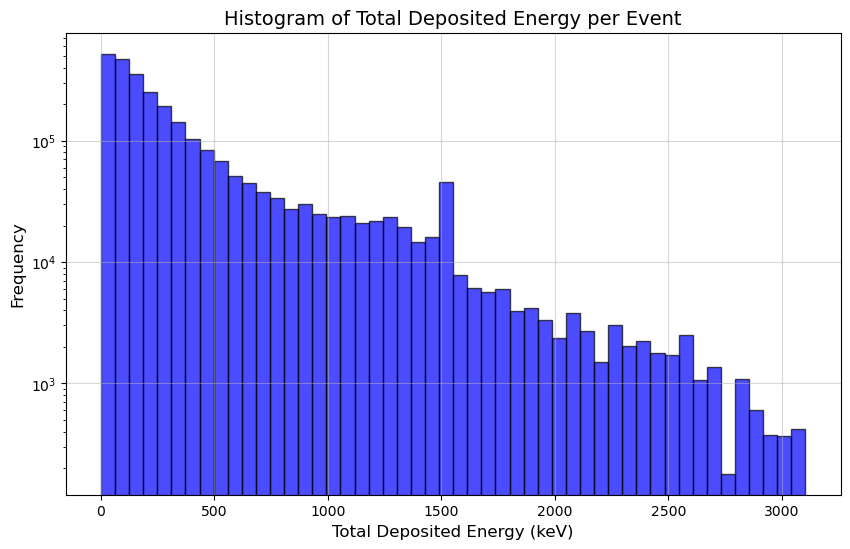

In [10]:
import matplotlib.pyplot as plt
# cut = (scaled_detector_hits['e_total']>=0)
# Calculate total deposited energy per event
scaled_detector_hits['e_total'] = scaled_detector_hits.groupby('event')['edep_scaled'].transform('sum')

# Plot histogram of e_total
plt.figure(figsize=(10, 6))

plt.hist(scaled_detector_hits['e_total'], bins=50, alpha=0.7, color='blue', edgecolor='black', log=True)
plt.xlabel('Total Deposited Energy (keV)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of Total Deposited Energy per Event', fontsize=14)
plt.grid(alpha=0.5)
plt.show()


In [13]:
import numpy as np

scaled_detector_hits['e_total_initial'] = scaled_detector_hits.groupby('event')['edep'].transform('sum')

# Calculate total deposited energy per event after applying activeness
scaled_detector_hits['e_total_scaled'] = scaled_detector_hits.groupby('event')['edep_scaled'].transform('sum')

# Compute histogram data without plotting
hist_initial, _ = np.histogram(scaled_detector_hits['e_total_initial'], bins=bins)
hist_scaled, _ = np.histogram(scaled_detector_hits['e_total_scaled'], bins=bins)

# Save the binned data
np.savez("histogram_k42.npz", bins=bins, hist_initial=hist_initial, hist_scaled=hist_scaled)


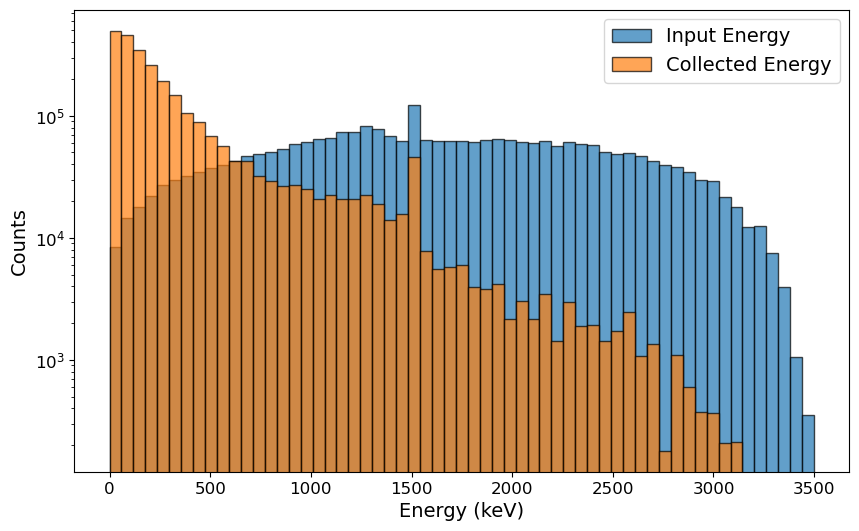

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Load saved histogram data
data = np.load("/nas/longleaf/home/kbhimani/EH-Drift/Analysis/alpha_sims/histogram_k42.npz")
bins = data['bins']
hist_initial = data['hist_initial']
hist_scaled = data['hist_scaled']

# Plot
plt.figure(figsize=(10, 6))
plt.hist(bins[:-1], bins=bins, weights=hist_initial, alpha=0.7, color='tab:blue', edgecolor='black', label='Input Energy', log=True)
plt.hist(bins[:-1], bins=bins, weights=hist_scaled, alpha=0.7, color='tab:orange', edgecolor='black', label='Collected Energy', log=True)

plt.xlabel('Energy (keV)', fontsize=14)
plt.ylabel('Counts', fontsize=14)
plt.legend(fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()
